# Seasonal Agriculture Performance Analysis

**Major Project - VOIS AICTE Batch, 2026-2027**

**Domain: Agriculture**

**Tools: Python, Pandas, NumPy, Matplotlib, and SciPy**

In this project, I use the farm dataset to compare agricultural performance across the Kharif, Rabi, and Zaid seasons. I look at yield, profit, environmental conditions, resource use, crop choice, and irrigation.

## Questions I want to answer

1. How does farm performance change from one season to another?
2. Which environmental and resource patterns are linked with better results?
3. Which crops and irrigation methods perform well within each season?
4. Are rainfall, temperature, soil moisture, and other conditions related to yield or profit?
5. Which seasons have better economic and water-use outcomes?
6. Are there unusual records that should be checked?
7. What practical lessons can be taken from the results?

## 1. Load the data

I first import the libraries used in this project and load the CSV file. The CSV is in the same folder as this notebook, so a relative path keeps the notebook portable.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("seasonal_agriculture_performance_dataset.csv")
df = pd.read_csv(DATA_PATH)

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 2. Get to know the dataset

Each row represents one farm observation for a season. The categorical columns describe the location, crop, season, and irrigation method. The numeric columns contain weather, soil, input, production, cost, revenue, profit, water-use, and disease-risk information.

In [22]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print("\nColumn data types:")
print(df.dtypes)

print("\nUnique values in key categorical columns:")
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nSeason counts:")
print(df["Season"].value_counts())

Rows: 4,000
Columns: 28

Column data types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR  

## 3. Quick data dictionary

These are the main columns used in the analysis:

| Column | Meaning |
|---|---|
| `Farm_ID` | Unique identifier for a farm record |
| `State`, `District` | Location information |
| `Crop` | Crop grown on the farm |
| `Season` | Kharif, Rabi, or Zaid season |
| `Farm_Area_Hectares` | Farm size in hectares |
| `Yield_Tonnes_Ha` | Crop yield per hectare |
| `Production_Tonnes` | Total crop production |
| `Market_Price_INR_Tonne` | Selling price per tonne |
| `Total_Cost_INR` | Total cost of farming |
| `Revenue_INR` | Revenue earned from production |
| `Profit_INR` | Revenue minus total cost |
| `Water_Used_m3` | Water used in cubic metres |
| `Water_Efficiency_t_per_1000m3` | Tonnes produced per 1,000 cubic metres of water |
| `Disease_Pest_Risk_pct` | Recorded disease or pest risk percentage |

## 3. Check the data before using it

Before doing any calculations, I check missing values, duplicate rows, unusual negative values, and whether the production, revenue, cost, and profit fields are internally consistent.

## 4. Check the data before using it

Before doing any calculations, I check missing values, duplicate rows, unusual negative values, and whether the production, revenue, cost, and profit fields are internally consistent.

## 4. Clean the data

I check the missing and duplicate records before continuing. Missing numeric values are filled with the median of their column because the median is less affected by extreme values. I do not remove duplicate rows unless the data check shows that they are actually duplicates.

In [24]:
missing_before = df.isna().sum().sort_values(ascending=False)
duplicates_before = df.duplicated().sum()

quality_report = pd.DataFrame({
    "missing_values": missing_before,
    "missing_percent": (missing_before / len(df) * 100).round(2)
})
print(quality_report[quality_report["missing_values"] > 0])
print(f"\nDuplicate rows: {duplicates_before}")

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

print("\nMissing values after median imputation:", int(df.isna().sum().sum()))

                              missing_values  missing_percent
Rainfall_mm                               48             1.20
Soil_Moisture_pct                         40             1.00
Calculated_Production_Tonnes              32             0.80
Yield_Tonnes_Ha                           32             0.80
Production_Difference                     32             0.80

Duplicate rows: 0

Missing values after median imputation: 0


## 5. Create a few useful measures

The dataset already contains revenue, cost, and profit. I add ROI and profit margin so that farms can be compared using percentages as well as absolute profit. I also label each row as either profitable or loss-making and flag unusually high yields for a closer look.

In [25]:
df["ROI_pct"] = np.where(
    df["Total_Cost_INR"] != 0,
    df["Profit_INR"] / df["Total_Cost_INR"] * 100,
    np.nan
)
df["Profit_Margin_pct"] = np.where(
    df["Revenue_INR"] != 0,
    df["Profit_INR"] / df["Revenue_INR"] * 100,
    np.nan
)
df["Outcome"] = np.where(df["Profit_INR"] >= 0, "Profit", "Loss")

# I use the IQR rule to flag unusually high yields for review.
yield_q1, yield_q3 = np.percentile(df["Yield_Tonnes_Ha"], [25, 75])
yield_iqr = yield_q3 - yield_q1
yield_upper_fence = yield_q3 + 1.5 * yield_iqr
df["Yield_Outlier"] = df["Yield_Tonnes_Ha"] > yield_upper_fence

print(df[["Profit_INR", "ROI_pct", "Profit_Margin_pct", "Outcome"]].head())
print(f"\nUpper yield outlier threshold: {yield_upper_fence:.2f} tonnes/ha")
print(f"Yield outliers: {df['Yield_Outlier'].sum():,}")

   Profit_INR  ROI_pct  Profit_Margin_pct Outcome
0      -11852   -27.78             -38.47    Loss
1     -451950   -91.79          -1,118.66    Loss
2     -124744   -39.57             -65.49    Loss
3      -95704   -32.28             -47.68    Loss
4     -144352   -42.71             -74.56    Loss

Upper yield outlier threshold: 5.50 tonnes/ha
Yield outliers: 302


## 6. Compare performance across seasons

This is the main comparison in the project. I compare yield, production, revenue, cost, profit, ROI, water efficiency, disease risk, and the percentage of loss-making farms.

In [26]:
season_order = ["Kharif", "Rabi", "Zaid"]
season_summary = (
    df.groupby("Season")
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
          Median_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "median"),
          Avg_Production_Tonnes=("Production_Tonnes", "mean"),
          Avg_Revenue_INR=("Revenue_INR", "mean"),
          Avg_Cost_INR=("Total_Cost_INR", "mean"),
          Avg_Profit_INR=("Profit_INR", "mean"),
          Median_Profit_INR=("Profit_INR", "median"),
          Avg_ROI_pct=("ROI_pct", "mean"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
          Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean")
      )
      .reindex(season_order)
)
season_summary["Loss_Rate_pct"] = (
    df.assign(Loss=df["Profit_INR"] < 0)
      .groupby("Season")["Loss"]
      .mean().mul(100).reindex(season_order)
)
season_summary.round(2)

,Farms,Avg_Yield_Tonnes_Ha,Median_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Median_Profit_INR,Avg_ROI_pct,Avg_Water_Efficiency,Avg_Disease_Risk_pct,Loss_Rate_pct
Season,,,,,,,,,,,,
Kharif,1779,5.63,1.94,46.31,"710,719.06","531,804.41","178,914.65","38,808.00",35.45,5.89,54.47,42.21
Rabi,1627,5.04,1.67,41.49,"601,526.05","513,836.58","87,689.47","-3,187.00",17.60,5.19,40.48,51.14
Zaid,594,4.64,1.46,38.89,"519,171.90","543,976.73","-24,804.82","-62,144.00",-2.47,4.41,38.22,64.48


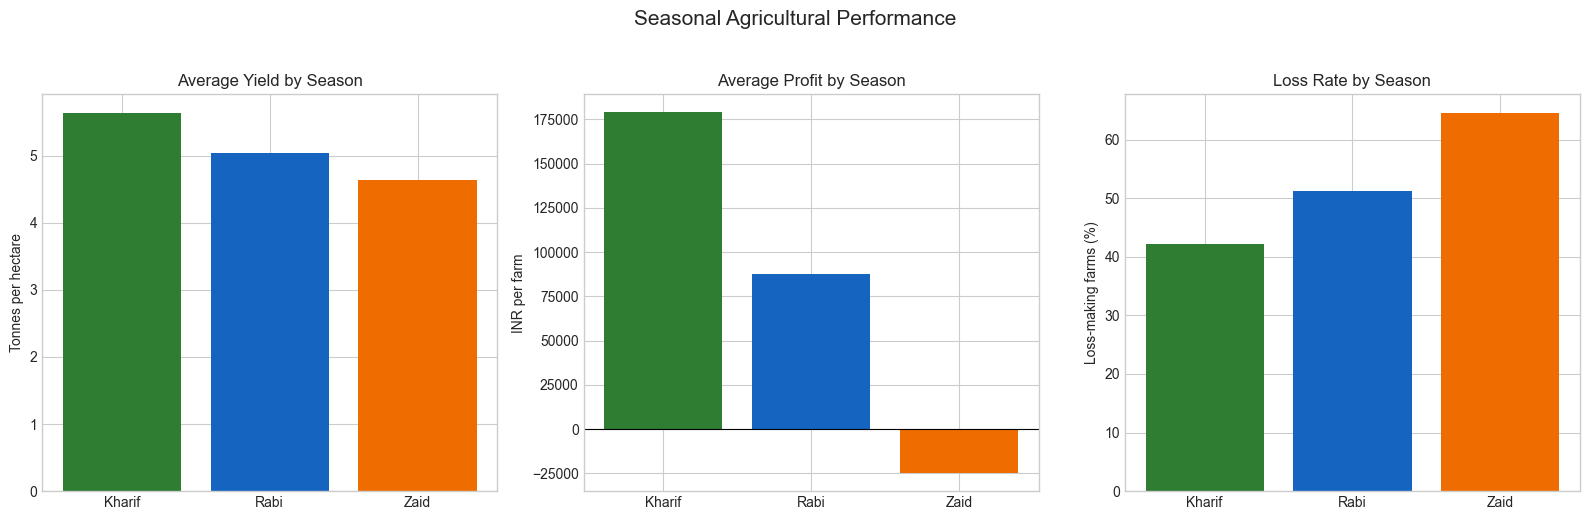

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#2E7D32", "#1565C0", "#EF6C00"]

axes[0].bar(season_summary.index, season_summary["Avg_Yield_Tonnes_Ha"], color=colors)
axes[0].set_title("Average Yield by Season")
axes[0].set_ylabel("Tonnes per hectare")

axes[1].bar(season_summary.index, season_summary["Avg_Profit_INR"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Average Profit by Season")
axes[1].set_ylabel("INR per farm")

axes[2].bar(season_summary.index, season_summary["Loss_Rate_pct"], color=colors)
axes[2].set_title("Loss Rate by Season")
axes[2].set_ylabel("Loss-making farms (%)")

plt.suptitle("Seasonal Agricultural Performance", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

### What the seasonal results mean

I compare both the mean and the median because a few unusually profitable farms can pull the average upward. The table and chart should be used together when deciding which season appears stronger.

## 7. Look at environmental conditions and resource use

Next, I compare rainfall, temperature, humidity, soil moisture, fertilizer, water use, water efficiency, and disease or pest risk. These comparisons help me understand the conditions surrounding the seasonal results.

In [28]:
environment_summary = (
    df.groupby("Season")[[
        "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct",
        "Fertilizer_kg_ha", "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
        "Disease_Pest_Risk_pct"
    ]].mean().reindex(season_order)
)
environment_summary.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,849.20,28.45,71.81,31.15,187.08,"6,102.20",5.89,54.47
Rabi,437.62,23.49,57.89,24.07,185.41,"5,846.99",5.19,40.48
Zaid,304.65,31.04,52.01,19.28,184.64,"6,419.89",4.41,38.22


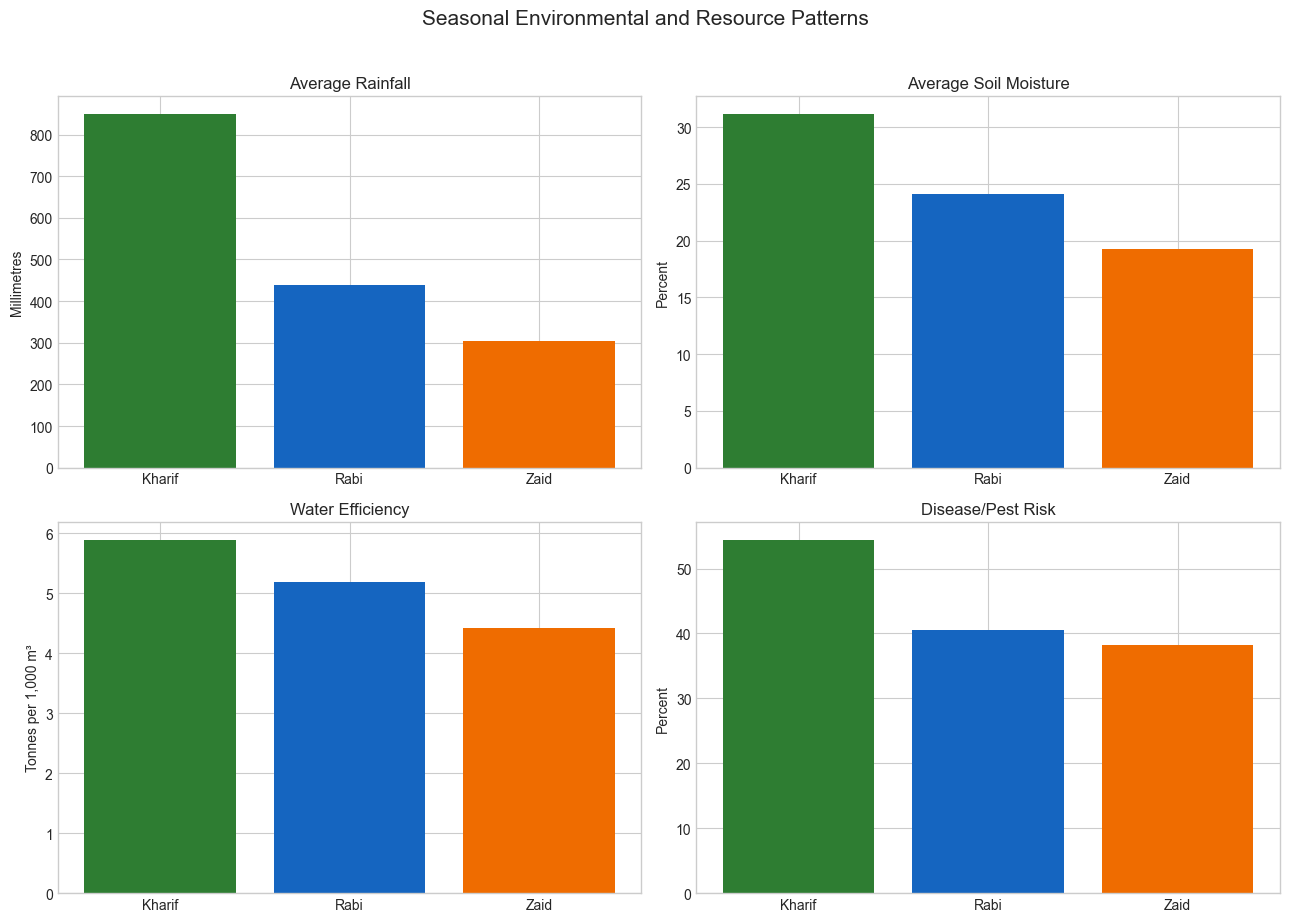

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plots = [
    ("Rainfall_mm", "Average Rainfall", "Millimetres"),
    ("Soil_Moisture_pct", "Average Soil Moisture", "Percent"),
    ("Water_Efficiency_t_per_1000m3", "Water Efficiency", "Tonnes per 1,000 m³"),
    ("Disease_Pest_Risk_pct", "Disease/Pest Risk", "Percent")
]
for ax, (col, title, ylabel) in zip(axes.ravel(), plots):
    ax.bar(environment_summary.index, environment_summary[col], color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
plt.suptitle("Seasonal Environmental and Resource Patterns", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 8. Compare crops within each season

Overall seasonal averages can hide differences between crops. I therefore compare crop-season groups using yield, profit, median profit, water efficiency, loss rate, and the number of farms. Groups with fewer than 20 observations are left out of the ranking so that very small groups do not dominate the comparison.

In [30]:
crop_season = (
    df.groupby(["Season", "Crop"])
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Median_Profit=("Profit_INR", "median"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
          Loss_Rate=("Outcome", lambda values: (values == "Loss").mean() * 100)
      )
      .reset_index()
)
crop_season_reliable = crop_season[crop_season["Farms"] >= 20].sort_values(
    ["Season", "Avg_Profit"], ascending=[True, False]
)
crop_season_reliable.round(2)

,Season,Crop,Farms,Avg_Yield,Avg_Profit,Median_Profit,Avg_Water_Efficiency,Loss_Rate
6,Kharif,Sugarcane,125,53.46,"1,000,790.81","940,895.00",36.00,8.00
0,Kharif,Chilli,185,1.73,"954,380.42","705,116.00",3.26,14.59
1,Kharif,Cotton,215,1.37,"216,999.55","136,193.00",2.13,27.91
2,Kharif,Groundnut,193,1.48,"108,265.44","87,406.00",3.58,33.16
4,Kharif,Pulses,221,1.04,"43,338.90","57,156.00",3.35,37.10
3,Kharif,Maize,234,2.97,"-39,332.67","-9,883.50",6.05,53.42
5,Kharif,Rice,314,2.70,"-64,903.40","-39,903.50",2.17,58.60
7,Kharif,Wheat,292,2.25,"-105,871.87","-57,248.50",4.76,68.15
14,Rabi,Sugarcane,129,43.29,"731,612.86","622,229.00",27.92,14.73
8,Rabi,Chilli,163,1.47,"638,572.50","470,004.00",2.89,21.47


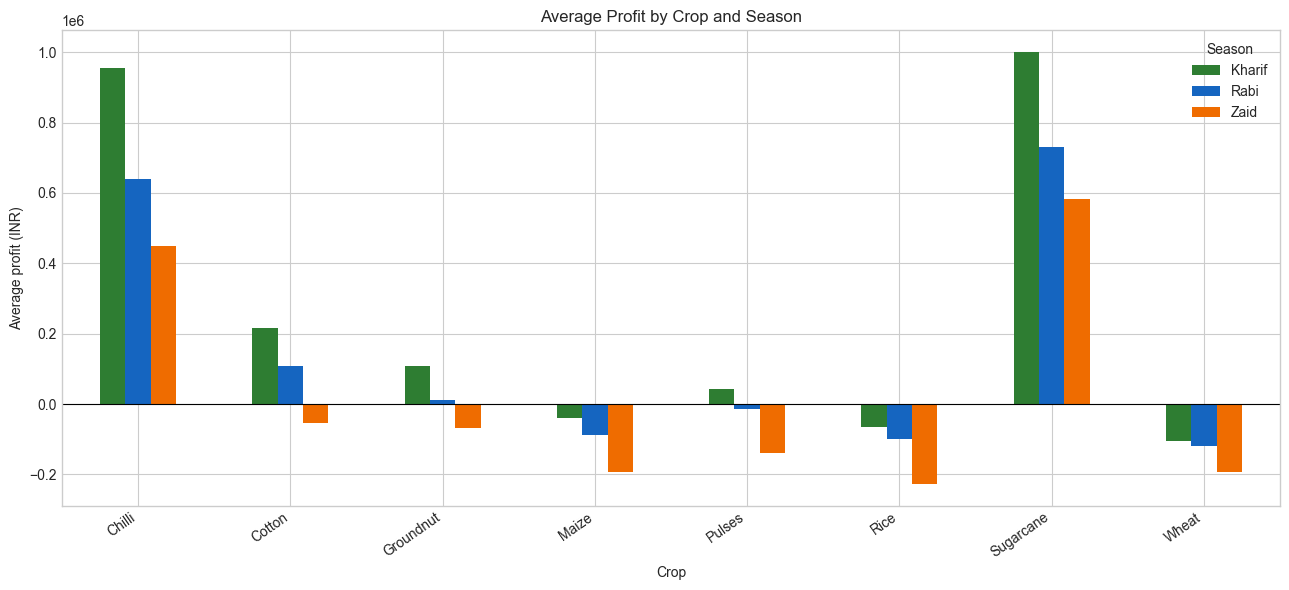

In [31]:
fig, ax = plt.subplots(figsize=(13, 6))
pivot_profit = crop_season_reliable.pivot(index="Crop", columns="Season", values="Avg_Profit")
pivot_profit.reindex(columns=season_order).plot(kind="bar", ax=ax, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Average Profit by Crop and Season")
ax.set_xlabel("Crop")
ax.set_ylabel("Average profit (INR)")
ax.legend(title="Season")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 9. Compare irrigation methods

I compare irrigation methods within each season using yield, profit, water used, water efficiency, and loss rate. This is a descriptive comparison only; farms using different methods may also differ in location, crop, soil, or cost.

In [32]:
irrigation_summary = (
    df.groupby(["Season", "Irrigation_Method"])
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Water_Used=("Water_Used_m3", "mean"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
          Loss_Rate=("Outcome", lambda values: (values == "Loss").mean() * 100)
      )
      .reset_index()
      .sort_values(["Season", "Avg_Profit"], ascending=[True, False])
)
irrigation_summary.round(2)

,Season,Irrigation_Method,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Loss_Rate
0,Kharif,Drip,405,7.26,"317,222.07","5,953.37",6.80,34.07
2,Kharif,Rainfed,463,5.70,"158,974.13","3,687.52",8.85,44.28
1,Kharif,Flood,590,4.98,"133,373.83","8,229.27",3.64,46.27
3,Kharif,Sprinkler,321,4.66,"116,880.49","5,863.27",4.62,42.06
4,Rabi,Drip,370,6.11,"187,843.22","5,911.41",6.05,39.46
7,Rabi,Sprinkler,293,5.31,"76,502.07","6,129.09",4.64,52.22
5,Rabi,Flood,526,5.06,"58,824.80","7,766.83",3.48,55.13
6,Rabi,Rainfed,438,3.93,"45,232.48","3,298.29",6.87,55.48
11,Zaid,Sprinkler,120,6.14,"57,909.40","7,324.41",4.86,54.17
8,Zaid,Drip,140,5.85,"21,291.84","5,837.99",5.30,60.00


## 10. Compare profitability and cost efficiency

A large farm can have a large total profit simply because it has more land. To make the comparison fairer, I calculate profit per hectare. I also calculate the revenue-to-cost ratio to see how much revenue is generated for each rupee spent.

In [33]:
df["Profit_per_Hectare_INR"] = np.where(
    df["Farm_Area_Hectares"] != 0,
    df["Profit_INR"] / df["Farm_Area_Hectares"],
    np.nan
)
df["Revenue_to_Cost_Ratio"] = np.where(
    df["Total_Cost_INR"] != 0,
    df["Revenue_INR"] / df["Total_Cost_INR"],
    np.nan
)

profitability_summary = (
    df.groupby("Season")[[
        "Profit_per_Hectare_INR",
        "Revenue_to_Cost_Ratio"
    ]].mean().reindex(season_order)
)

profitability_summary.round(2)

,Profit_per_Hectare_INR,Revenue_to_Cost_Ratio
Season,,
Kharif,"21,881.81",1.35
Rabi,"10,361.68",1.18
Zaid,"-2,636.52",0.98


## 11. Explore input use and yield

Here I examine whether fertilizer, pesticide, and water use move together with yield and profit. These results show relationships in this dataset, but they cannot prove that changing one input would cause a particular result.

Input and outcome correlations:
                    Yield_Tonnes_Ha  Profit_INR
Fertilizer_kg_ha               0.00       -0.07
Pesticide_Litre_ha            -0.01       -0.03
Water_Used_m3                  0.39        0.19
Yield_Tonnes_Ha                1.00        0.49
Profit_INR                     0.49        1.00


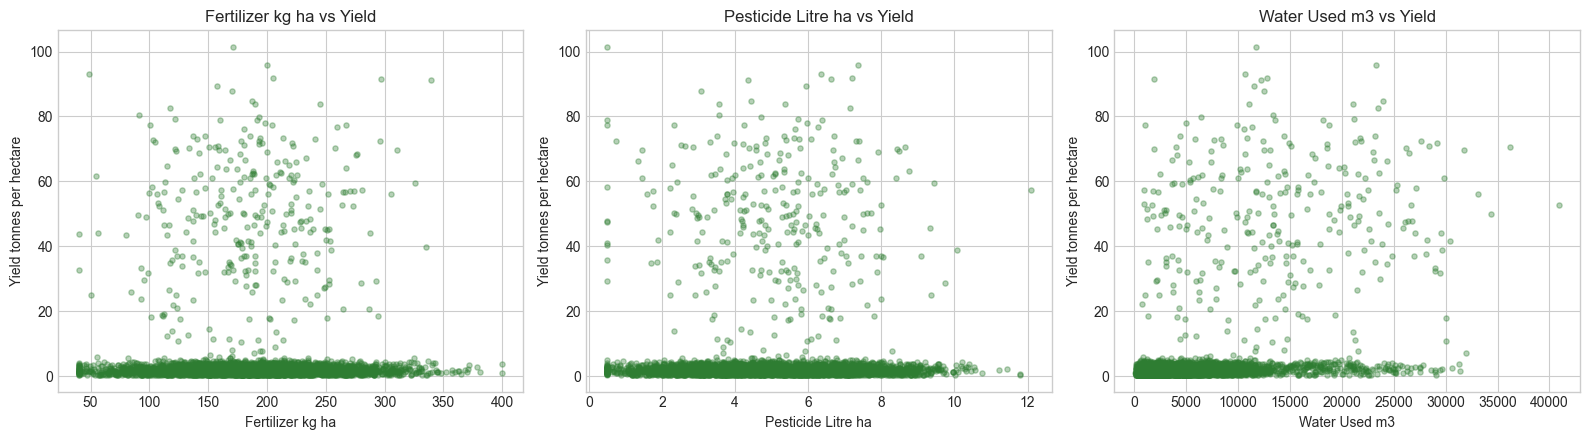

In [34]:
input_columns = [
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]

input_correlations = df[input_columns].corr()
print("Input and outcome correlations:")
print(input_correlations[["Yield_Tonnes_Ha", "Profit_INR"]].round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, input_column in zip(
    axes,
    ["Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3"]
):
    ax.scatter(
        df[input_column],
        df["Yield_Tonnes_Ha"],
        alpha=0.35,
        s=14,
        color="#2E7D32"
    )
    ax.set_xlabel(input_column.replace("_", " "))
    ax.set_ylabel("Yield tonnes per hectare")
    ax.set_title(f"{input_column.replace('_', ' ')} vs Yield")

plt.tight_layout()
plt.show()

## 12. Compare crops and irrigation together

An irrigation method may work well for one crop but not for another. This table groups the data by season, crop, and irrigation method so that useful combinations can be identified for further study.

In [35]:
crop_irrigation_summary = (
    df.groupby(["Season", "Crop", "Irrigation_Method"])
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit=("Profit_INR", "mean"),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
          Loss_Rate=("Outcome", lambda values: (values == "Loss").mean() * 100)
      )
      .reset_index()
      .sort_values(
          ["Season", "Crop", "Avg_Profit"],
          ascending=[True, True, False]
      )
)

reliable_crop_irrigation = crop_irrigation_summary[
    crop_irrigation_summary["Farms"] >= 10
]

reliable_crop_irrigation.round(2)

,Season,Crop,Irrigation_Method,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Loss_Rate
0,Kharif,Chilli,Drip,50,1.93,"1,192,769.22",3.65,10.00
1,Kharif,Chilli,Flood,57,1.74,"951,598.93",2.21,19.30
2,Kharif,Chilli,Rainfed,45,1.52,"833,154.73",4.55,13.33
3,Kharif,Chilli,Sprinkler,33,1.70,"763,297.42",2.72,15.15
4,Kharif,Cotton,Drip,45,1.57,"321,031.13",2.38,20.00
...,...,...,...,...,...,...,...,...
89,Zaid,Sugarcane,Flood,15,35.59,"421,108.87",16.42,6.67
92,Zaid,Wheat,Drip,19,2.08,"-141,617.79",4.45,84.21
94,Zaid,Wheat,Rainfed,25,1.62,"-152,593.92",5.66,96.00
95,Zaid,Wheat,Sprinkler,16,1.94,"-196,138.25",3.66,87.50


## 13. Look at the distribution of yield and profit

Boxplots show the typical value, the spread of the data, and unusual observations. This gives a better picture than averages alone, especially when a few farms have very high or very low results.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5924\2923070851.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(seasonal_yield, labels=season_order, patch_artist=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_5924\2923070851.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(seasonal_profit, labels=season_order, patch_artist=True)


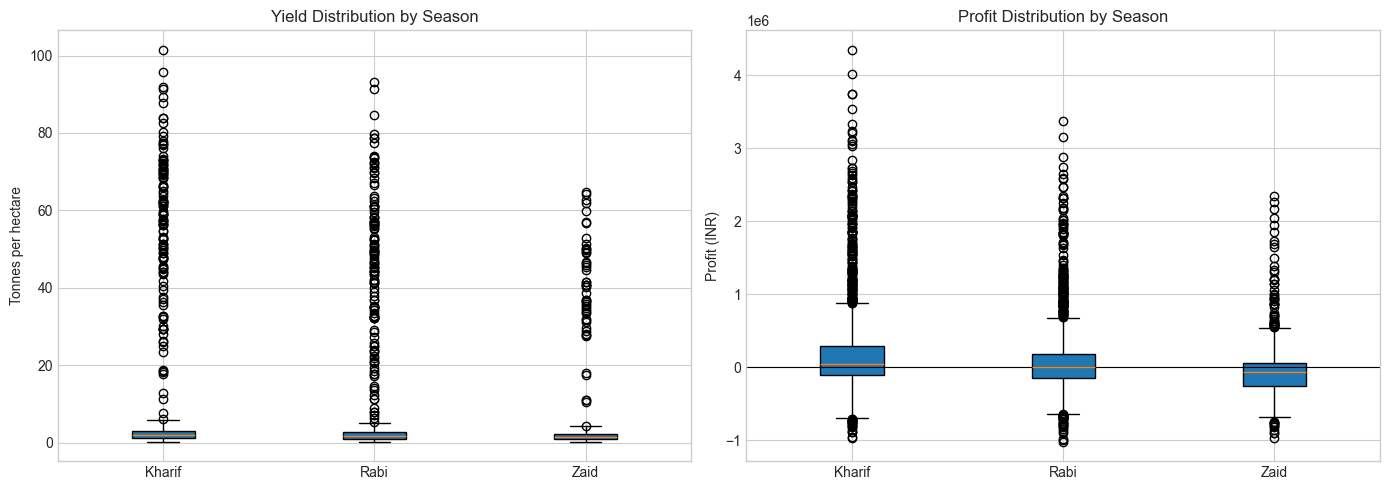

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seasonal_yield = [
    df.loc[df["Season"] == season, "Yield_Tonnes_Ha"]
    for season in season_order
]
seasonal_profit = [
    df.loc[df["Season"] == season, "Profit_INR"]
    for season in season_order
]

axes[0].boxplot(seasonal_yield, labels=season_order, patch_artist=True)
axes[0].set_title("Yield Distribution by Season")
axes[0].set_ylabel("Tonnes per hectare")

axes[1].boxplot(seasonal_profit, labels=season_order, patch_artist=True)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Profit Distribution by Season")
axes[1].set_ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

## 14. Check whether regional patterns are similar

Seasonal results may not be the same everywhere. I compare states by season and keep only state-season groups with at least 10 observations. This helps avoid drawing conclusions from very small groups.

State-season groups with at least 10 observations:


,State,Season,Farms,Avg_Yield_Tonnes_Ha,Avg_Profit_INR,Loss_Rate_pct,Avg_Water_Efficiency
0,Andhra Pradesh,Kharif,240,5.68,"169,315.52",43.33,6.12
1,Andhra Pradesh,Rabi,204,3.47,"26,315.71",53.43,4.16
2,Andhra Pradesh,Zaid,85,4.45,"-84,084.87",70.59,4.07
3,Gujarat,Kharif,221,6.34,"217,051.33",39.82,6.38
4,Gujarat,Rabi,200,5.44,"82,846.20",52.50,5.18
5,Gujarat,Zaid,67,4.07,"-106,929.61",71.64,4.10
6,Karnataka,Kharif,209,6.46,"201,226.21",41.15,5.89
7,Karnataka,Rabi,206,4.57,"70,952.61",50.00,5.33
8,Karnataka,Zaid,74,6.62,"23,310.91",58.11,5.30
9,Madhya Pradesh,Kharif,226,5.99,"134,242.40",44.69,6.22


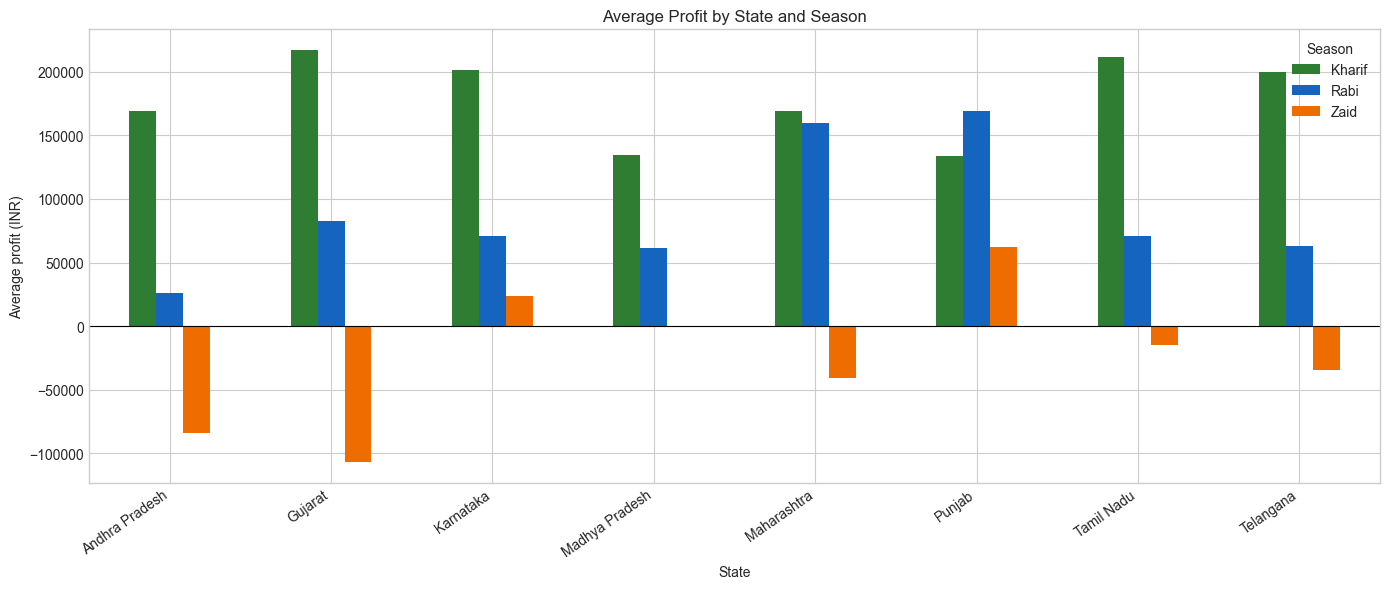

In [37]:
state_season_summary = (
    df.groupby(["State", "Season"])
      .agg(
          Farms=("Farm_ID", "count"),
          Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
          Avg_Profit_INR=("Profit_INR", "mean"),
          Loss_Rate_pct=("Outcome", lambda values: (values == "Loss").mean() * 100),
          Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .reset_index()
)

reliable_state_season = state_season_summary[
    state_season_summary["Farms"] >= 10
].sort_values(["State", "Avg_Profit_INR"], ascending=[True, False])

print("State-season groups with at least 10 observations:")
display(reliable_state_season.round(2))

state_season_profit = reliable_state_season.pivot(
    index="State", columns="Season", values="Avg_Profit_INR"
)

state_season_profit.reindex(columns=season_order).plot(
    kind="bar", figsize=(14, 6), color=colors
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Average Profit by State and Season")
plt.xlabel("State")
plt.ylabel("Average profit (INR)")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

## 15. Test the seasonal profit difference

The averages show differences between seasons, but I also use a Kruskal-Wallis test to check whether the profit distributions differ statistically. This test is useful here because profit may be skewed and may contain extreme values. A significant result shows a difference between groups, not proof that season alone caused it.

In [38]:
from scipy.stats import kruskal

profit_groups = [
    df.loc[df["Season"] == season, "Profit_INR"].dropna()
    for season in season_order
]

kruskal_statistic, kruskal_p_value = kruskal(*profit_groups)

print(f"Kruskal-Wallis statistic: {kruskal_statistic:.3f}")
print(f"p-value: {kruskal_p_value:.6f}")

if kruskal_p_value < 0.05:
    print("Result: Profit distributions differ significantly across seasons at the 5% level.")
else:
    print("Result: There is not enough evidence of a significant profit difference across seasons at the 5% level.")

Kruskal-Wallis statistic: 101.926
p-value: 0.000000
Result: Profit distributions differ significantly across seasons at the 5% level.


## 16. Examine relationships between conditions and outcomes

Correlation shows whether two numeric variables move together in a linear way. It does not show cause and effect. Some variables, such as production, revenue, yield, and water efficiency, are also mathematically related, so those correlations need to be interpreted carefully.

In [39]:
correlation_cols = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct",
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha", "Fertilizer_kg_ha",
    "Pesticide_Litre_ha", "Seed_Quality_Score", "Market_Price_INR_Tonne",
    "Total_Cost_INR", "Water_Used_m3", "Disease_Pest_Risk_pct",
    "Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3"
]
corr = df[correlation_cols].corr(numeric_only=True)
print("Correlations with yield:")
print(corr["Yield_Tonnes_Ha"].sort_values(ascending=False).round(3))
print("\nCorrelations with profit:")
print(corr["Profit_INR"].sort_values(ascending=False).round(3))

Correlations with yield:
Yield_Tonnes_Ha                  1.00
Water_Efficiency_t_per_1000m3    0.91
Profit_INR                       0.49
Water_Used_m3                    0.39
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Disease_Pest_Risk_pct            0.01
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Potassium_kg_ha                  0.00
Fertilizer_kg_ha                 0.00
Seed_Quality_Score              -0.01
Pesticide_Litre_ha              -0.01
Market_Price_INR_Tonne          -0.38
Name: Yield_Tonnes_Ha, dtype: float64

Correlations with profit:
Profit_INR                       1.00
Water_Efficiency_t_per_1000m3    0.49
Yield_Tonnes_Ha                  0.49
Market_Price_INR_Tonne           0.23
Water_Used_m3                    0.19
Rainfall_mm                      0.11
Soil_Moisture_pct                0.0

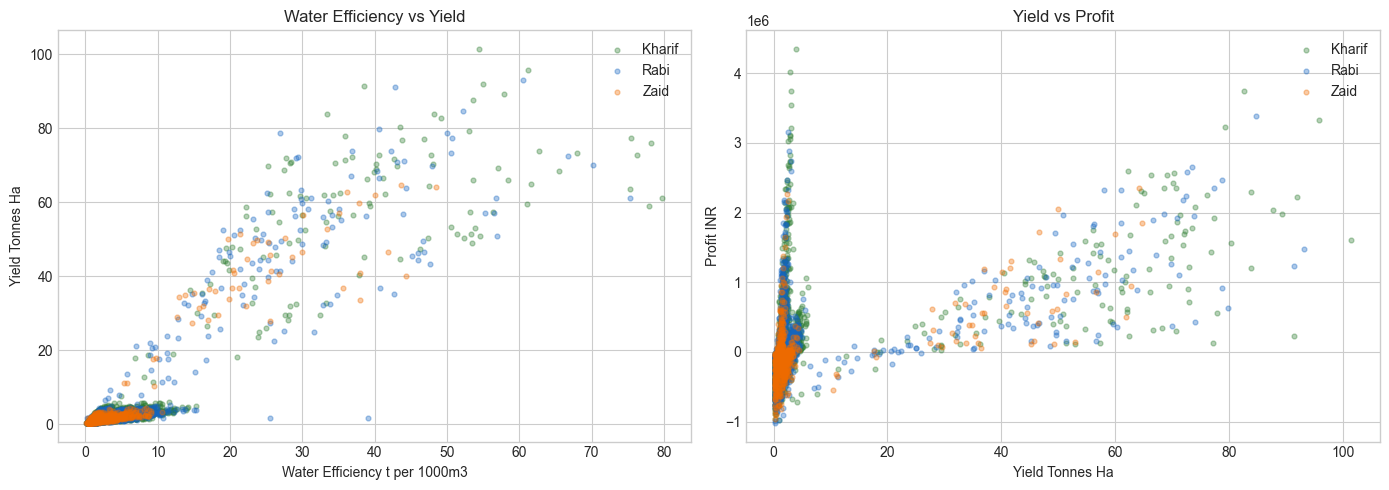

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, x, y, title in [
    (axes[0], "Water_Efficiency_t_per_1000m3", "Yield_Tonnes_Ha", "Water Efficiency vs Yield"),
    (axes[1], "Yield_Tonnes_Ha", "Profit_INR", "Yield vs Profit")
]:
    for season, color in zip(season_order, colors):
        subset = df[df["Season"] == season]
        ax.scatter(subset[x], subset[y], s=12, alpha=0.35, label=season, color=color)
    ax.set_xlabel(x.replace("_", " "))
    ax.set_ylabel(y.replace("_", " "))
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

## 17. Investigate unusual records and limitations

The IQR rule flags unusually high yields. These records are not automatically mistakes; they may reflect a genuinely high-performing farm or a data issue. I display the most extreme records so they can be checked.

In [41]:
outliers = (
    df[df["Yield_Outlier"]]
    .sort_values("Yield_Tonnes_Ha", ascending=False)
    [["Farm_ID", "State", "District", "Crop", "Season", "Farm_Area_Hectares",
      "Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR", "Water_Efficiency_t_per_1000m3"]]
)
print(f"Number of high-yield outliers: {len(outliers):,}")
outliers.head(15)

Number of high-yield outliers: 302


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,6.32,101.44,641.10,1608291,54.42
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79,"1,424.40",3330582,61.16
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,93.13,648.18,1471529,60.55
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,7.65,91.98,703.65,2216708,55.03
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,0.82,91.46,75.00,234320,38.58
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,5.72,91.32,522.35,1236801,42.82
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,7.48,89.34,668.26,1984818,57.87
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,7.66,87.76,672.24,2041678,53.67
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75,"1,249.21",3378879,52.19
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,6.38,83.79,534.58,1200815,48.22


The dataset has some important limitations. It is observational, so the comparisons do not prove cause and effect. Some state-district combinations may not represent real geography and should be checked. Yield is strongly skewed, so I report both the mean and median. There is also no year or date column, so this notebook cannot study long-term trends.

## 18. Summarize the main results

The next cell prints the main findings from the cleaned data. This keeps the conclusions connected to the values calculated from the dataset.

In [42]:
best_profit_season = season_summary["Avg_Profit_INR"].idxmax()
worst_profit_season = season_summary["Avg_Profit_INR"].idxmin()
best_yield_season = season_summary["Avg_Yield_Tonnes_Ha"].idxmax()
lowest_loss_season = season_summary["Loss_Rate_pct"].idxmin()
best_water_season = season_summary["Avg_Water_Efficiency"].idxmax()
best_profit_per_hectare_season = profitability_summary["Profit_per_Hectare_INR"].idxmax()

print(f"Records analyzed: {len(df):,}")
print(f"1. Highest average profit: {best_profit_season} ({season_summary.loc[best_profit_season, 'Avg_Profit_INR']:,.0f} INR).")
print(f"2. Lowest average profit: {worst_profit_season} ({season_summary.loc[worst_profit_season, 'Avg_Profit_INR']:,.0f} INR).")
print(f"3. Highest average yield: {best_yield_season} ({season_summary.loc[best_yield_season, 'Avg_Yield_Tonnes_Ha']:.2f} tonnes/ha).")
print(f"4. Lowest loss rate: {lowest_loss_season} ({season_summary.loc[lowest_loss_season, 'Loss_Rate_pct']:.2f}%).")
print(f"5. Highest average water efficiency: {best_water_season} ({season_summary.loc[best_water_season, 'Avg_Water_Efficiency']:.2f} tonnes/1,000 m³).")
print(f"6. Highest profit per hectare: {best_profit_per_hectare_season} ({profitability_summary.loc[best_profit_per_hectare_season, 'Profit_per_Hectare_INR']:,.0f} INR/ha).")
print(f"7. Kruskal-Wallis p-value for seasonal profit differences: {kruskal_p_value:.6f}")

Records analyzed: 4,000
1. Highest average profit: Kharif (178,915 INR).
2. Lowest average profit: Zaid (-24,805 INR).
3. Highest average yield: Kharif (5.63 tonnes/ha).
4. Lowest loss rate: Kharif (42.21%).
5. Highest average water efficiency: Kharif (5.89 tonnes/1,000 m³).
6. Highest profit per hectare: Kharif (21,882 INR/ha).
7. Kruskal-Wallis p-value for seasonal profit differences: 0.000000


## 19. Recommendations

**Use the strongest seasonal results as a starting point, not a universal rule.** Kharif appears stronger in this dataset, but local weather, crop suitability, and input prices should also be considered.

**Pay closer attention to financial risk in Zaid.** Its results suggest that farmers should carefully estimate irrigation costs, expected prices, crop choice, and likely profit before planting.

**Choose crops according to the season.** A crop that performs well in one season may not be the best choice in another, so the crop-season table is more useful than one overall crop ranking.

**Track water efficiency alongside yield.** High yield is more useful when it does not require excessive water. The irrigation results can suggest options for field trials, but they should not be treated as proof that one method causes better performance.

**Check unusual high-yield records.** Before using them as benchmarks, confirm the units, crop definitions, and original production records.

**Collect better data in future.** Adding the year, farm history, and verified locations would make it possible to study long-term trends and build more reliable forecasts.

## 20. Final summary

### Questions answered

- **How does performance change across seasons?** The seasons differ in yield, profit, loss rate, water efficiency, environmental conditions, and resource use.
- **Which season performs best financially?** The automatic results cell identifies the season with the highest and lowest average profit.
- **Are the differences statistically meaningful?** The Kruskal-Wallis result shows whether the seasonal profit distributions differ at the 5% level.
- **Are the patterns similar across locations?** The state-by-season table and chart show whether the pattern is consistent in states with enough observations.

### Main findings

- I used both means and medians because extreme yield and profit values affect the averages.
- Crop choice and irrigation should be compared within each season rather than ranked using one overall result.
- Rainfall, soil moisture, disease risk, water efficiency, and input use help provide context for the yield and profit results.
- Correlations show relationships in the data, but they do not prove that one factor caused another.

### What I would do next

- Use these results as a starting point for local crop, irrigation, and financial planning.
- Add several years of data and verify the locations before using the results for forecasting or major decisions.

## 21. Final conclusion

This analysis shows that agricultural performance is not the same in every season. In this dataset, Kharif has the strongest overall results, while Zaid carries more financial risk. The differences can be seen in yield, profit, loss rate, water efficiency, and environmental conditions. These findings support season-specific planning, but they should be treated as evidence from this dataset rather than as proof that season alone determines farm performance.